# 1. The dataset

The images are Human Protein Atlas (HPA) small-intestine immunohistochemistry slides.
Every file in the project joins on the slide filename
`{tissue}_{gene}_{sex}_{age}_{patientId}.jpg`.

All numbers in this notebook are recomputed from the raw files. The last section checks
them against the research log (`research/LOG.md`). Run All takes about 2 minutes.


In [1]:
import os, csv, collections, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from nb_style import (ROOT, p, TRAIN_COLOR, VAL_COLOR, USABLE_C, UNUSABLE_C,
                      set_seed, verify, verify_summary)

set_seed(42)
HUMAN_CSV    = p("review_tool", "results", "final_clean_dataset_20260802.csv")
V2_CSV       = p("models", "vlm_labels", "vertex_gemini_2_5_flash_v2_labels.csv")
ENS_CSV      = p("models", "vlm_labels", "ensemble_cascade_labels.csv")
COMBINED_CSV = p("review_tool", "results", "combined_human_machine_20260818.csv")
REVIEW_IMGS  = p("review_tool", "webapp", "review_images")
BULK_IMGS    = p("data_bulk", "images")

def rows(path):
    with open(path, newline="", encoding="utf-8") as fh:
        return list(csv.DictReader(fh))

human = rows(HUMAN_CSV)
print(f"human-labelled slides: {len(human)}")

human-labelled slides: 847


## 1. Example slides

Three slides graded usable and three graded unusable by the expert. A slide is usable if it
contains at least one readable stretch of villus epithelium (five or more adjacent cells
with clear apical and basal surfaces). Staining colour does not matter.


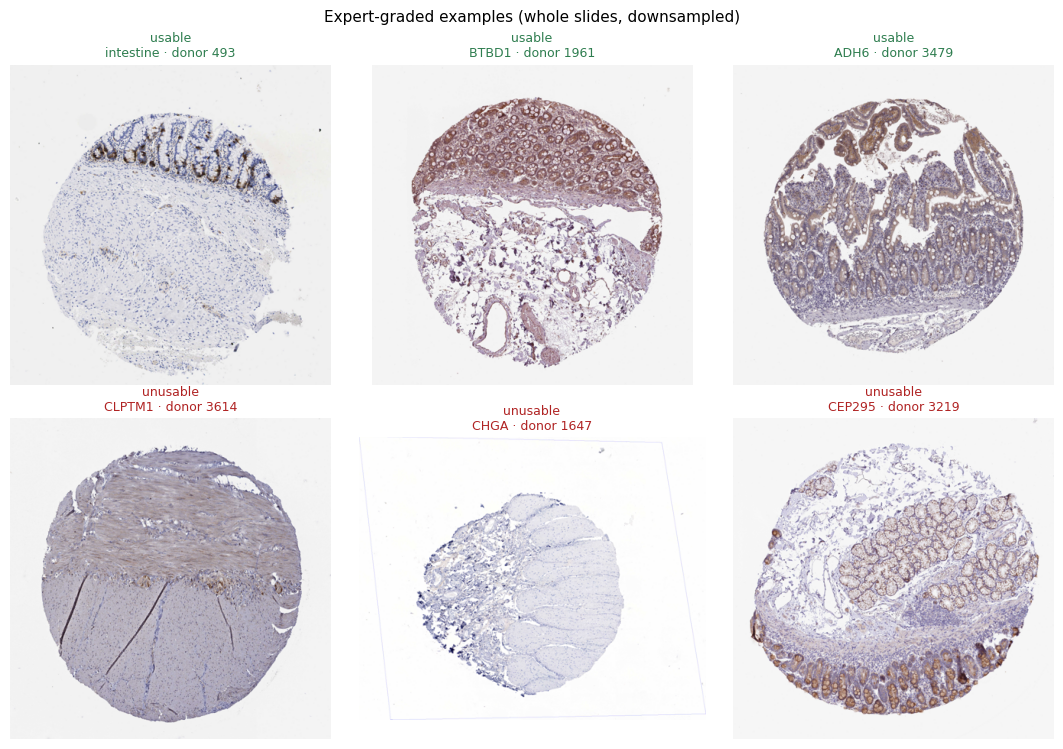

In [2]:
by = {"usable": [], "unusable": []}
for r in human:
    by[r["label"]].append(r["image_id"])
random.seed(42)
picks = random.sample(by["usable"], 3) + random.sample(by["unusable"], 3)

fig, axes = plt.subplots(2, 3, figsize=(11, 7.6))
for ax, fn in zip(axes.ravel(), picks):
    lab = "usable" if fn in by["usable"] else "unusable"
    with Image.open(os.path.join(REVIEW_IMGS, fn)) as im:
        im.thumbnail((420, 420))
        ax.imshow(im)
    ax.set_title(f"{lab}\n{fn.split('_')[1]} · donor {fn.rsplit('_',1)[1][:-4]}",
                 fontsize=9, color=(USABLE_C if lab == "usable" else UNUSABLE_C))
    ax.axis("off")
fig.suptitle("Expert-graded examples (whole slides, downsampled)", fontsize=11)
fig.tight_layout()
plt.show()

## 2. Data source and two constraints

The pool is every downloaded HPA small-intestine slide. Two facts, recomputed from the
filenames:

1. 16 donors have cancer morphology. All of their slides are excluded from training.
2. After exclusion only about 43 donors exist in HPA. More images can be downloaded, but
   no new donors.


In [3]:
CANCER_DONORS = {"1069", "1090", "1839", "1879", "1904", "2338", "2467", "2806",
                 "3049", "3548", "603", "604", "637", "700", "707", "997"}
pool = [f for f in os.listdir(BULK_IMGS) if f.lower().endswith(".jpg")]
donor_of = lambda f: f.rsplit(".", 1)[0].split("_")[-1]
cancer = [f for f in pool if donor_of(f) in CANCER_DONORS]
clean  = [f for f in pool if donor_of(f) not in CANCER_DONORS]
print(f"downloaded pool:        {len(pool):5d} slides, {len(set(map(donor_of, pool)))} donors")
print(f"cancer-donor slides:    {len(cancer):5d}  (excluded from everything)")
print(f"clean pool:             {len(clean):5d} slides, {len(set(map(donor_of, clean)))} donors")

downloaded pool:         8000 slides, 59 donors
cancer-donor slides:     2100  (excluded from everything)
clean pool:              5900 slides, 43 donors


## 3. Donor imbalance

Some donors contribute far more slides than others. This is why cross-validation is
grouped by donor (notebook 03): a model must be tested on donors it has never seen.


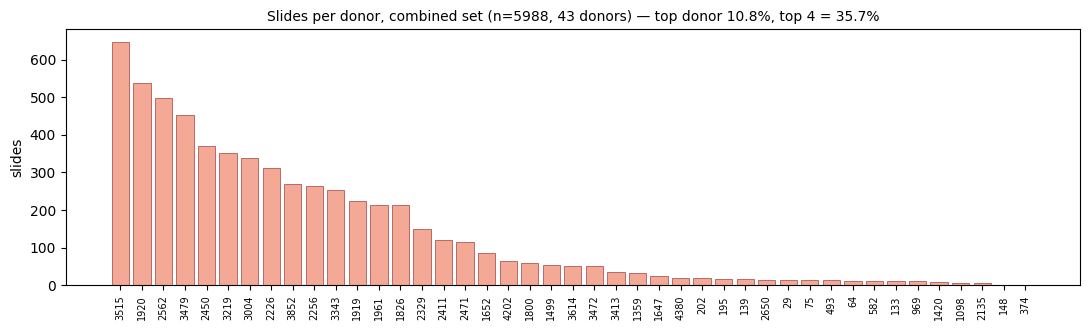

In [4]:
comb = rows(COMBINED_CSV)
cnt = collections.Counter(r["patient_id"] for r in comb)
ds, ns = zip(*cnt.most_common())
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(range(len(ns)), ns, color=TRAIN_COLOR, edgecolor=VAL_COLOR, linewidth=0.4)
ax.set_xticks(range(len(ds)), ds, rotation=90, fontsize=7)
ax.set_ylabel("slides")
top4 = sum(ns[:4]) / sum(ns)
ax.set_title(f"Slides per donor, combined set (n={sum(ns)}, {len(ds)} donors) — "
             f"top donor {ns[0]/sum(ns)*100:.1f}%, top 4 = {top4*100:.1f}%", fontsize=10)
fig.tight_layout(); plt.show()

## 4. Class balance

Four label sets exist. The expert set was deliberately enriched with likely-unusable
slides, so its unusable share is higher than HPA's natural 10 to 14%. Notebook 02
explains how each set was made.


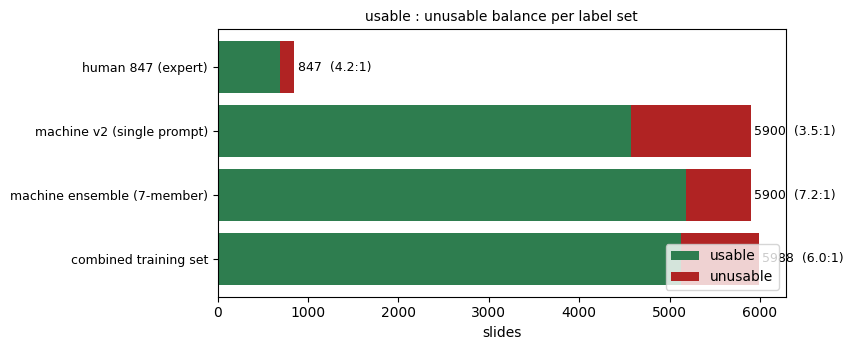

  human 847 (expert)               684 usable /  163 unusable   ratio 4.2:1
  machine v2 (single prompt)      4576 usable / 1324 unusable   ratio 3.5:1
  machine ensemble (7-member)     5178 usable /  722 unusable   ratio 7.2:1
  combined training set           5127 usable /  861 unusable   ratio 6.0:1


In [5]:
def counts(rws, lab_key="label"):
    c = collections.Counter(r[lab_key] for r in rws)
    return c["usable"], c["unusable"]

sets = {
    "human 847 (expert)":        counts(human),
    "machine v2 (single prompt)": counts([r for r in rows(V2_CSV) if r["label"] in ("usable","unusable")]),
    "machine ensemble (7-member)":counts([r for r in rows(ENS_CSV) if r["label"] in ("usable","unusable")]),
    "combined training set":      counts(comb),
}
fig, ax = plt.subplots(figsize=(8.6, 3.6))
ys = np.arange(len(sets))
us  = [v[0] for v in sets.values()]; un = [v[1] for v in sets.values()]
ax.barh(ys, us, color=USABLE_C, label="usable")
ax.barh(ys, un, left=us, color=UNUSABLE_C, label="unusable")
for i, (name, (u, n)) in enumerate(sets.items()):
    ax.text(u + n + 40, i, f"{u+n}  ({u/max(n,1):.1f}:1)", va="center", fontsize=9)
ax.set_yticks(ys, list(sets.keys()), fontsize=9)
ax.invert_yaxis(); ax.legend(loc="lower right"); ax.set_xlabel("slides")
ax.set_title("usable : unusable balance per label set", fontsize=10)
fig.tight_layout(); plt.show()
for name, (u, n) in sets.items():
    print(f"  {name:30s} {u:5d} usable / {n:4d} unusable   ratio {u/max(n,1):.1f}:1")

## 5. Check against the research log

Each headline number is recomputed from the CSVs and compared with the value in
`research/LOG.md`. A tick means they agree.


In [6]:
hu, hn = counts(human)
verify("human labels (rows)", len(human), 847, source="LOG 2026-08-02")
verify("human usable/unusable", [hu, hn], [684, 163], source="LOG 2026-08-02")
verify("human donors", len({r["patient_id"] for r in human}), 39, source="LOG 2026-08-02")

v2r = [r for r in rows(V2_CSV) if r["label"] in ("usable", "unusable")]
verify("v2 machine labels", len(v2r), 5900, source="LOG 2026-08-16")
verify("v2 usable/unusable", list(counts(v2r)), [4576, 1324], source="LOG 2026-08-16")

er = [r for r in rows(ENS_CSV) if r["label"] in ("usable", "unusable")]
verify("ensemble labels", len(er), 5900, source="LOG 2026-08-17")
verify("ensemble usable/unusable", list(counts(er)), [5178, 722], source="LOG 2026-08-17")
verify("ensemble donors", len({r["donor"] for r in er}), 43, source="LOG 2026-08-17")

verify("combined rows", len(comb), 5988, source="LOG 2026-08-18")
verify("combined human+machine",
       [sum(1 for r in comb if r["label_source"] == "human"),
        sum(1 for r in comb if r["label_source"] == "machine")],
       [847, 5141], source="LOG 2026-08-18")
overlap = {r["source_image"] for r in er} & {r["image_id"] for r in human}
verify("847∩5900 overlap", len(overlap), 759, source="LOG 2026-08-17")
verify("cancer slides excluded from pool", len(cancer), 2100, source="LOG 2026-08-09")

verify_summary()

  ✓  human labels (rows): computed 847  expected 847   [LOG 2026-08-02]
  ✓  human usable/unusable: computed [684, 163]  expected [684, 163]   [LOG 2026-08-02]
  ✓  human donors: computed 39  expected 39   [LOG 2026-08-02]
  ✓  v2 machine labels: computed 5900  expected 5900   [LOG 2026-08-16]
  ✓  v2 usable/unusable: computed [4576, 1324]  expected [4576, 1324]   [LOG 2026-08-16]
  ✓  ensemble labels: computed 5900  expected 5900   [LOG 2026-08-17]
  ✓  ensemble usable/unusable: computed [5178, 722]  expected [5178, 722]   [LOG 2026-08-17]
  ✓  ensemble donors: computed 43  expected 43   [LOG 2026-08-17]
  ✓  combined rows: computed 5988  expected 5988   [LOG 2026-08-18]
  ✓  combined human+machine: computed [847, 5141]  expected [847, 5141]   [LOG 2026-08-18]
  ✓  847∩5900 overlap: computed 759  expected 759   [LOG 2026-08-17]
  ✓  cancer slides excluded from pool: computed 2100  expected 2100   [LOG 2026-08-09]

VERIFICATION: 12/12 checks passed
